## Problem Statement

Given a set of features( Age,Sex, BMI (Body Mass Index),Children, Smoker, Region, Charges ), we want to predict the medical insurance charges for a person. 

**Problem Type**: Regression <br>
**Possible Preprocessing Steps**: Handling missing values, Encoding categorical variables, Feature scaling, Duplicate Detection and removal, Outlier Detection. <br>
**Possible Algorithms**: Linear Regression, Decision Tree Regression, Random Forest Regression, Support Vector Regression, Gradient Boosting Regression, etc. <br>



## Notebook Imports

In [66]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression , Perceptron
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor


import warnings
warnings.filterwarnings('ignore')


In [2]:
# load the data
df = pd.read_csv('data/medical_insurance.csv')

In [3]:
#printing the first 5 rows of the data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#printing the info of the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [5]:
#changing the smoker column to binary values to make it easier for the model to understand and process the data
df['smoker'].replace({'yes':1, 'no':0}, inplace=True)

In [6]:
#check the null count of the data 
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### The data contain no missing values in any of the columns 

In [7]:
duplicate_rows = df.duplicated().sum()
total_rows = df.shape[0]
duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")
print(f"Shape of the data ")


Number of duplicate rows: 1435
Percentage of duplicate rows: 51.77%
Shape of the data 


In [8]:
#check the duplicate indices 
duplicate_indices = df[df.duplicated()].index
duplicate_indices

Index([ 581, 1338, 1339, 1340, 1341, 1342, 1343, 1344, 1345, 1346,
       ...
       2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770, 2771],
      dtype='int64', length=1435)

In [9]:
#print the rows which are duplicated with index 581
df[df.duplicated()].loc[581]

age                19
sex              male
bmi             30.59
children            0
smoker              0
region      northwest
charges     1639.5631
Name: 581, dtype: object

In [10]:
df[(df.age == 19) & (df.sex == "male") & (df.bmi == 30.59)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,0,northwest,1639.5631
581,19,male,30.59,0,0,northwest,1639.5631
1581,19,male,30.59,0,0,northwest,1639.5631
1967,19,male,30.59,0,0,northwest,1639.5631


The data contain more than 50% duplicate rows. We will need to remove the duplicate rows to avoid bias in our model and to improve the performance of our model. <br> <br>
Rectifying the duplicate rows is not possible in this case as the duplicate rows have the same values in all the columns. Hence, we will remove the duplicate rows from the data. <br>

In [11]:
df.drop_duplicates(inplace=True)

duplicate_rows_after = df.duplicated().sum()
print(f"Number of duplicate rows after dropping duplicates: {duplicate_rows_after}")

Number of duplicate rows after dropping duplicates: 0


# EDA

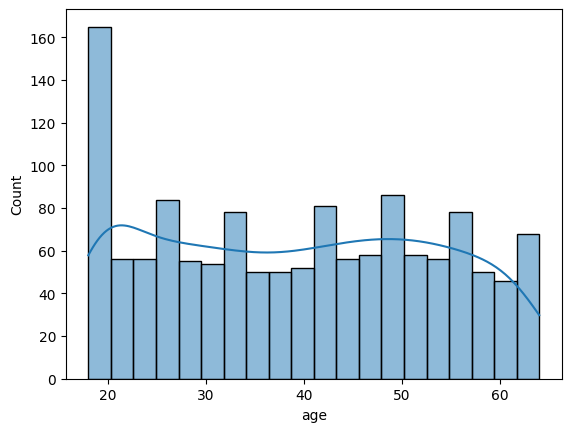

In [12]:
#distribution of age 
sns.histplot(df['age'], bins=20, kde=True)
plt.show()

The age distribution is right skewed with most of the people in the age group of 18-20. 

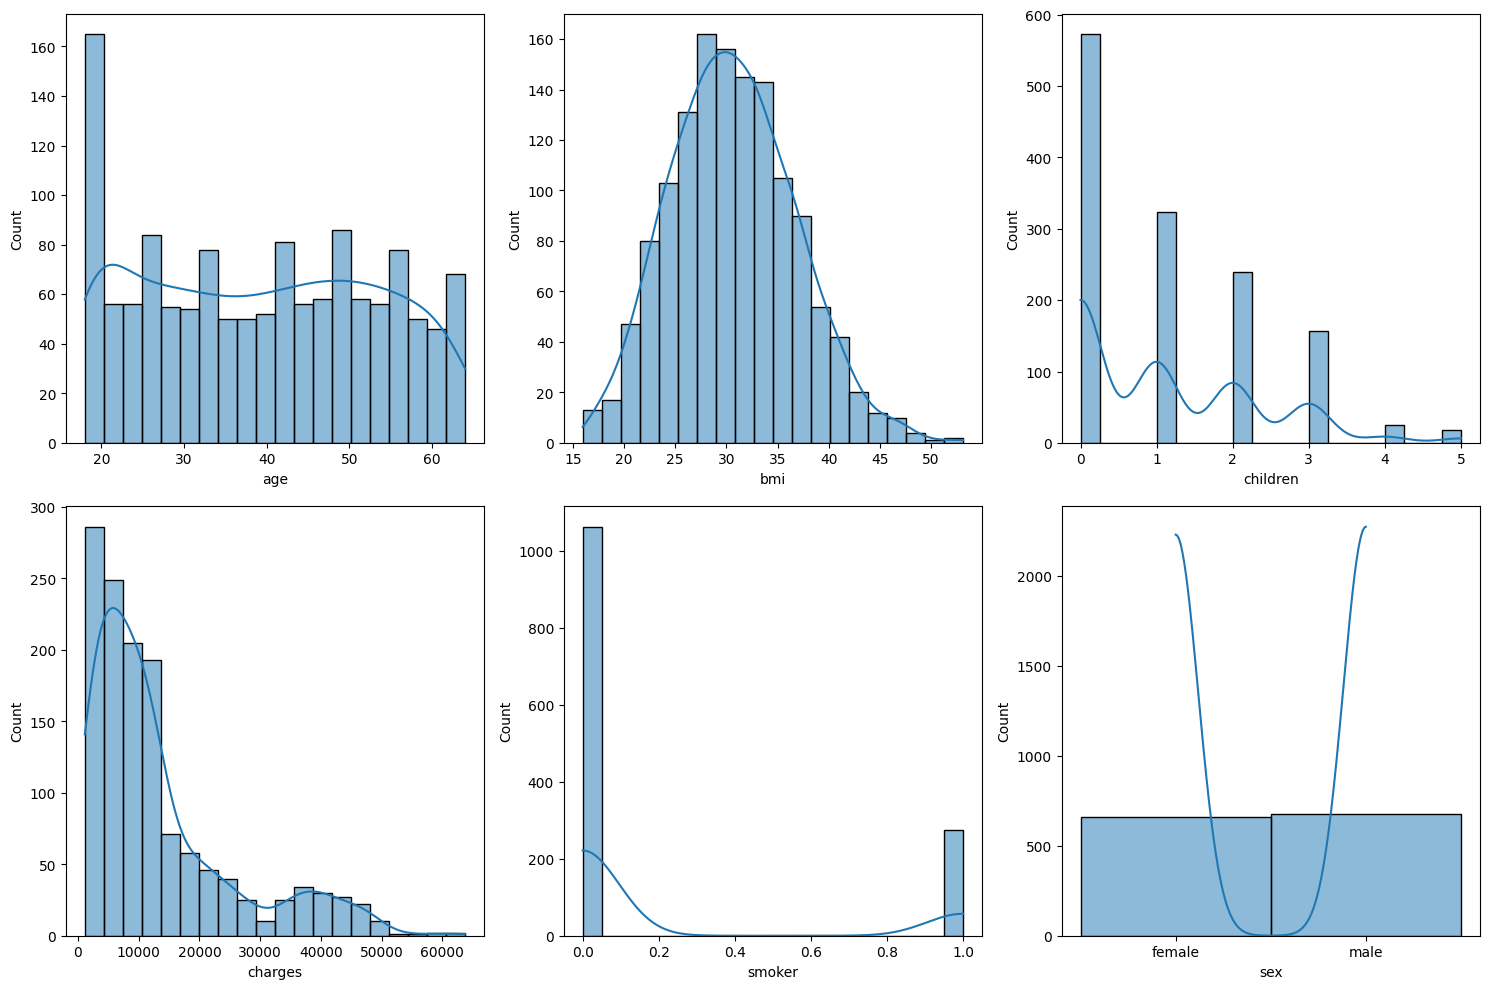

In [13]:
# show the hisplot of every column in the dataset  in a single figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0 ][0])
sns.histplot(df['bmi'], bins=20, kde=True, ax=axes[0][1])
sns.histplot(df['children'], bins=20, kde=True, ax=axes[0][2])
sns.histplot(df['charges'], bins=20, kde=True, ax=axes[1][0])
sns.histplot(df['smoker'], bins=20, kde=True, ax=axes[1][1])
sns.histplot(df['sex'], bins=20, kde=True, ax=axes[1][2])
plt.tight_layout()
plt.show()
                                            
        

- The BMI graph follows normal distribution with most of the people having BMI in the range of 25-35 range. This is expected as the data is about medical insurance and people with higher BMI are more likely to have health issues and hence, are more likely to have medical insurance. <br>
- On the other hand, the distribution of charges is right skewed with most of the people having charges in the range of 0-20000. This is expected as most of the people have low medical expenses and only a few people have high medical expenses. <br>

- The number of smokers is less than the number of non-smokers. The distribution is expected as smoking is a risk factor for various health issues, leading to higher medical costs. And mostly general population is aware about this fact.<br>


In [14]:
#check for inconsistencies in the data
df.describe()

,age,bmi,children,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,0.204936,13279.121487
std,14.044333,6.100468,1.205571,0.403806,12110.359656
min,18.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,0.000000,9386.161300
75%,51.000000,34.700000,2.000000,0.000000,16657.717450
max,64.000000,53.130000,5.000000,1.000000,63770.428010


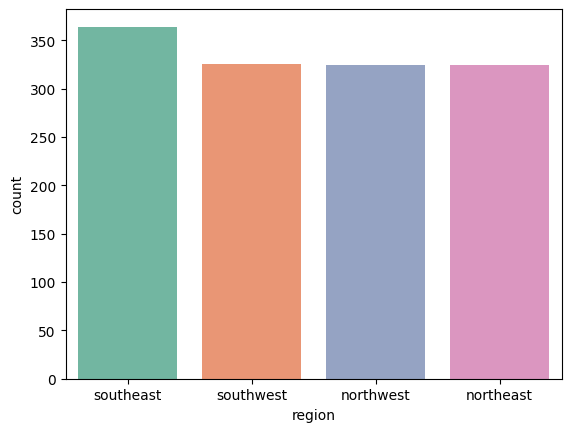

In [15]:
sns.barplot(df.region.value_counts() , orient='v' ,palette='Set2',fill=True , legend='auto')
# help(sns.barplot)
plt.show()

The distribution of the region variable is almost equal with the southeast region having slightly higher number of people. This is expected as the data is about medical insurance and people from all the regions are likely to have medical insurance. <br>

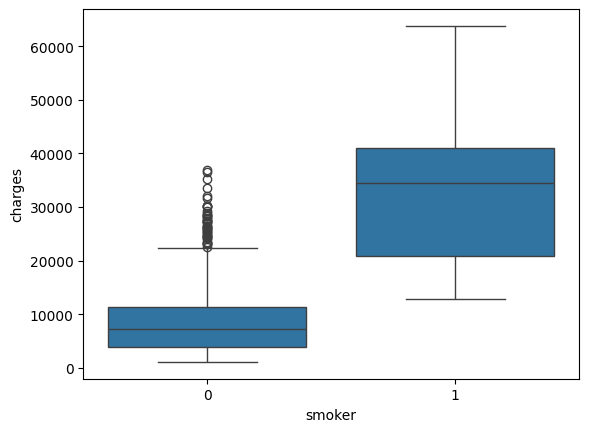

In [16]:
#check the distribution of charges for paitents who are smokers and non-smokers
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()


**Observations**
- The charges for smokers are significantly higher than the charges for non-smokers. 
- The median charges for smokers are around 35000 while the median charges for non-smokers are around 5000. 
- The medical expenses for smokers are more spread out with some smokers having very high medical expenses.
- There are a lot of outliers in the charges for non-smokers as they might have other factors contributing to their medical expenses.


In [17]:
# Data for all the non smokers whose charges are greater than 20000
non_smokers_high_charges = df[(df['smoker'] == 0) & (df['charges'] > 20000)]
non_smokers_high_charges_high_bmi = non_smokers_high_charges[non_smokers_high_charges['bmi'] > 30]
number_non_smokers_high_charges_high_bmi = non_smokers_high_charges_high_bmi.shape[0]
number_of_non_smokers_high_charges = non_smokers_high_charges.shape[0]
print(f"Number of non-smokers with high charges and high BMI: {number_non_smokers_high_charges_high_bmi}")
print(f"Number of non-smokers with high charges: {number_of_non_smokers_high_charges}")

Number of non-smokers with high charges and high BMI: 32
Number of non-smokers with high charges: 61


Approximately 50% of the non-smokers with high charges have high BMI. This indicates that BMI is a significant factor contributing to high medical expenses for non-smokers. It also suggests that non-smokers with high BMI are more likely to have health issues and hence, are more likely to have high medical expenses. <br>

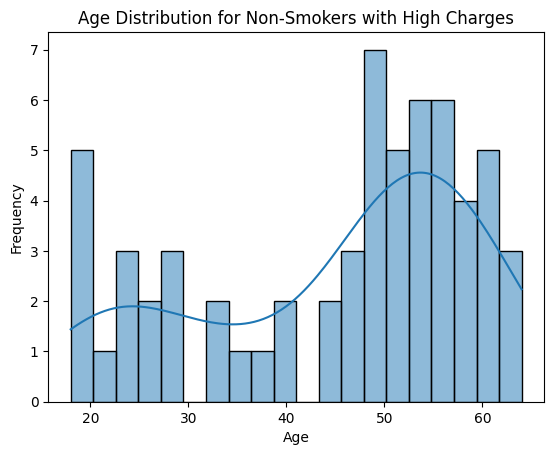

In [18]:
# Age distribution for non-smokers with high charges
sns.histplot(non_smokers_high_charges['age'], bins=20, kde=True)
plt.title('Age Distribution for Non-Smokers with High Charges')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The age distribution for non-smokers with high charges is right skewed with most of the people in the age group of 50-60+. This is expected as people in this age group are more likely to have health issues and hence, are more likely to have high medical expenses. <br>

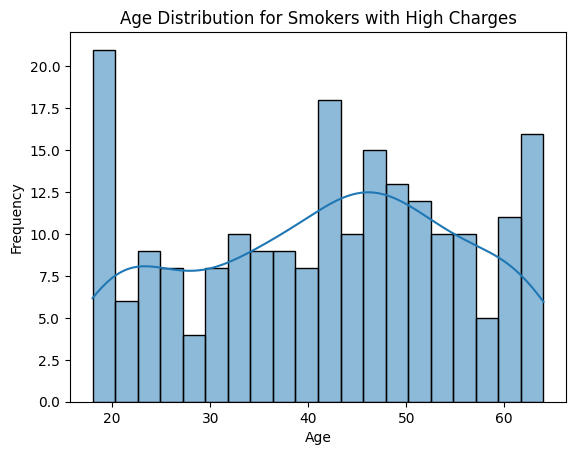

In [19]:
# Age distribution for smokers 
smokers_high_charges = df[(df['smoker'] == 1) & (df['charges'] > 20000)]
sns.histplot(smokers_high_charges['age'], bins=20, kde=True)
plt.title('Age Distribution for Smokers with High Charges')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The age distribution of smokers with high charges is almost equally distributed across all age groups with a slight increase in the age group of 40-50. This is expected as smoking is a risk factor for various health issues, leading to higher medical costs across all age groups. <br>

<Axes: xlabel='age', ylabel='charges'>

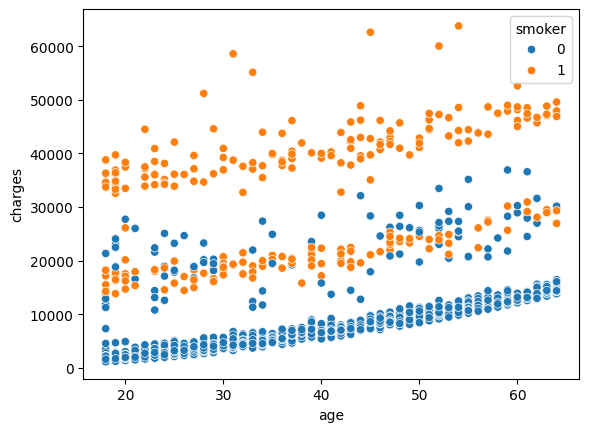

In [20]:
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)

- The charges for both smokers and non-smokers increase with age. This is because people tend to have more health issues as they age, leading to higher medical expenses. <br>

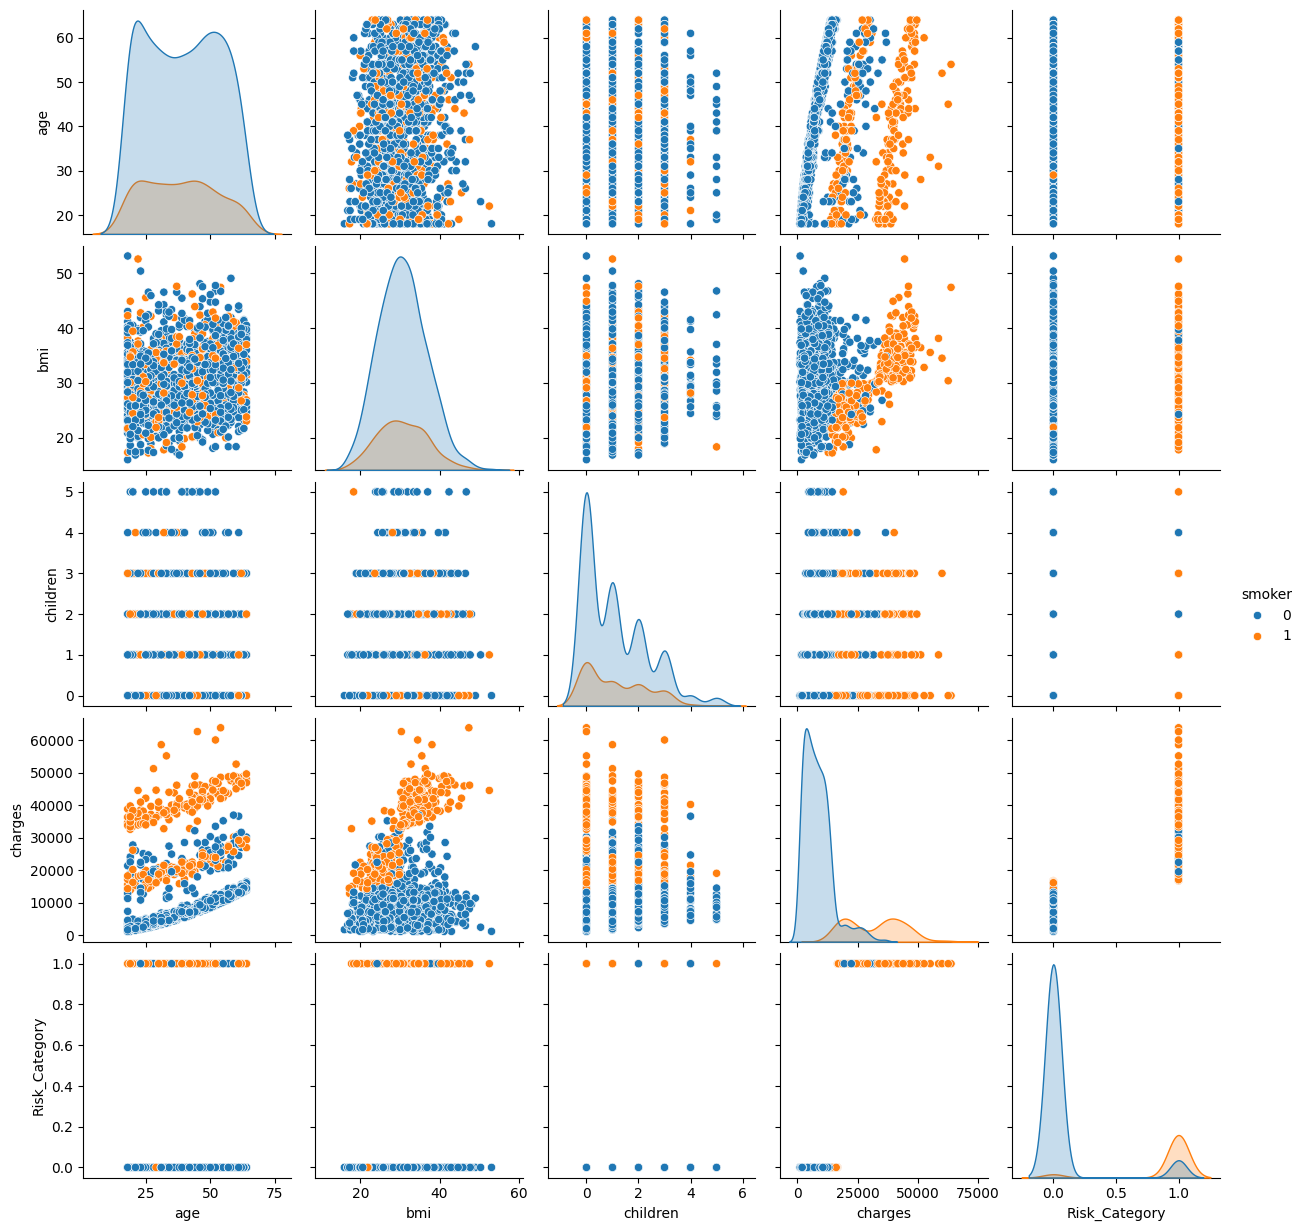

In [59]:
#plot pairplot for the data with hue as smoker
sns.pairplot(df, hue='smoker')

In [61]:
df[["age", 'bmi','children' , 'charges']].corr()

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


Age and BMI are significant factors contributing to high medical expenses. This is because of a general trend as we age and our BMI increases, leading to higher healthcare costs. <br>

<Axes: xlabel='children', ylabel='charges'>

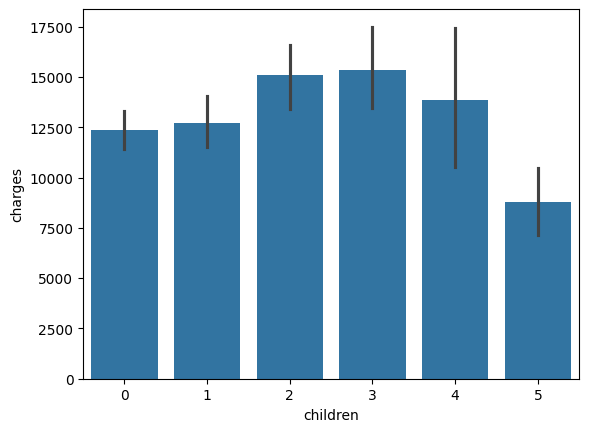

In [62]:
#plot the mean charges for each person having children 
sns.barplot(x='children', y='charges', data=df)

I could not find any significant relationship between the number of children and the charges.  <br>

In [23]:
charges_75 = df['charges'].quantile(0.75)
print(f"75th percentile of charges: {charges_75}")

df['Risk_Category'] = df['charges'].apply(lambda x: 1 if x > charges_75 else 0)


75th percentile of charges: 16657.71745


<Axes: xlabel='Risk_Category'>

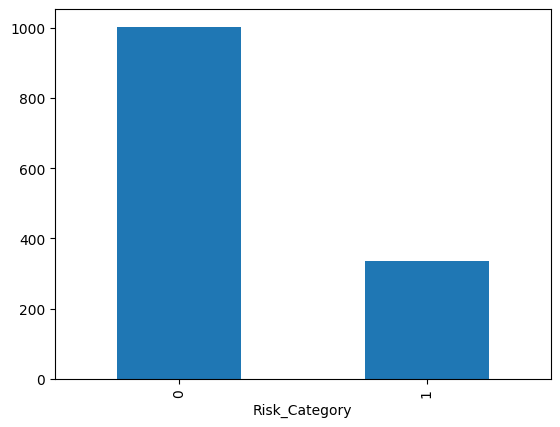

In [25]:
df["Risk_Category"].value_counts().plot(kind='bar')

The number of persons having high risk of health issues is less than the number of persons having low risk of health issues. 

<Axes: xlabel='Risk_Category'>

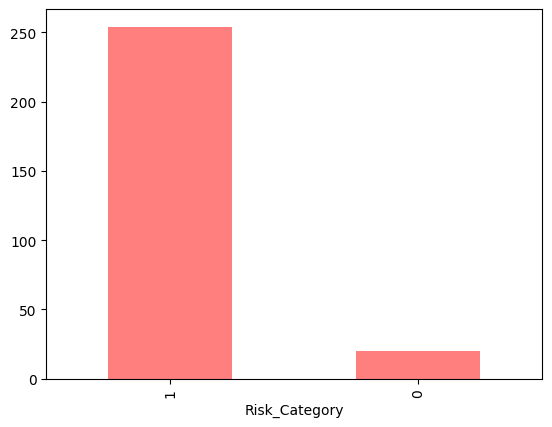

In [26]:
df[df["smoker"] == 1]["Risk_Category"].value_counts().plot(kind='bar', color='red', alpha=0.5, label='Smokers')

Almost all the persons having high risk of health issues are smokers. This indicates that smoking is a significant factor contributing to high medical expenses. It also suggests that smokers are more likely to have health issues and hence, are more likely to have high medical expenses. 

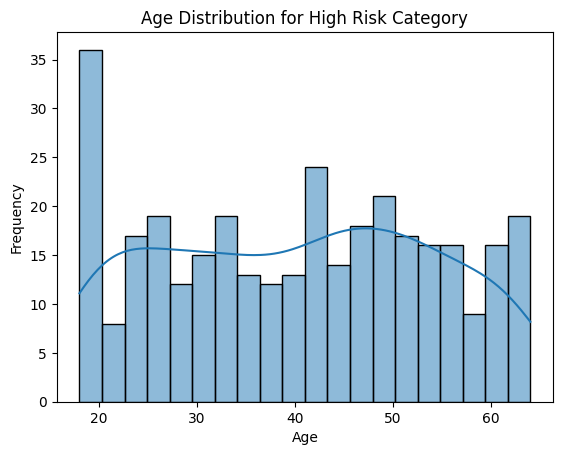

In [28]:
#age distribution for high risk category
high_risk_category = df[df['Risk_Category'] == 1]
sns.histplot(high_risk_category['age'], bins=20, kde=True)
plt.title('Age Distribution for High Risk Category')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The age distribution is very similar what it was for smokers with high charges. This indicates that age is also a significant factor contributing to high medical expenses for smokers. 

In [29]:
X = df.drop('charges', axis=1)
y = df['charges']
y_classification = df['Risk_Category']


In [30]:
#train test 80 20 split for regression and classification
train_indices = df.sample(frac=0.8, random_state=42).index
X_train = X.loc[train_indices]
y_train = y.loc[train_indices]
y_classification_train = y_classification.loc[train_indices]
X_test = X.drop(train_indices)
y_test = y.drop(train_indices)
y_classification_test = y_classification.drop(train_indices)


In [41]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# One-hot encode the categorical features
categorical_features = ['sex', 'region']
encoder = OneHotEncoder()
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])
# Standardize the numerical features
numerical_features = ['age', 'bmi', 'children', 'smoker']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numerical_features])
X_test_scaled = scaler.transform(X_test[numerical_features])
# Combine the encoded categorical features and scaled numerical features
X_train_final = np.concatenate((X_train_scaled, X_train_encoded.toarray()), axis=1)
X_test_final = np.concatenate((X_test_scaled, X_test_encoded.toarray()), axis=1)


In [78]:
from sklearn.linear_model import LinearRegression 
lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train)
y_pred_lin = lin_reg.predict(X_test_final)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f"Linear Regression - MSE: {mse_lin}, R2 Score: {r2_lin}")



Linear Regression - MSE: 35778471.73901257, R2 Score: 0.7485556376193372


In [79]:
# apply polynomial regression with degree 2
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_final)
X_test_poly = poly.transform(X_test_final)
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_poly, y_train)
y_pred_poly = lin_reg_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Regression (degree=2) - MSE: {mse_poly}, R2 Score: {r2_poly}")


Polynomial Regression (degree=2) - MSE: 20402581.039498366, R2 Score: 0.856614502211881


In [80]:
# apply polynomial regression with degree 3
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train_final)
X_test_poly3 = poly3.transform(X_test_final)
lin_reg_poly3 = LinearRegression()
lin_reg_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = lin_reg_poly3.predict(X_test_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)
print(f"Polynomial Regression (degree=3) - MSE: {mse_poly3}, R2 Score: {r2_poly3}")

Polynomial Regression (degree=3) - MSE: 21000218.032738153, R2 Score: 0.8524144219570158


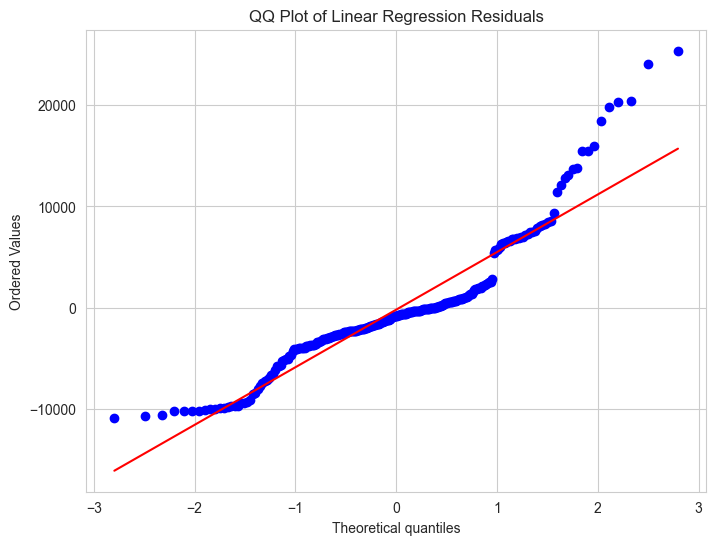

In [81]:
linear_reg_residual = y_test - y_pred_lin
#create a qq plot for the residuals of the linear regression model
import scipy.stats as stats

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
stats.probplot(linear_reg_residual, dist="norm", plot=plt)
plt.title('QQ Plot of Linear Regression Residuals')
plt.show()


The qq plot for the residuals of the linear regression model shows that the residuals are not normally distributed. This indicates that the linear regression model is not a good fit for the data. The residuals are right skewed with some outliers. This indicates that there are some data points that are not well explained by the linear regression model.

# Classification Algorithms 

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)

# Binary target (already 0/1 in this notebook)
y_train_cls = y_classification_train.astype(int)
y_test_cls = y_classification_test.astype(int)

rows = []
conf_mats = {}
roc_data = {}

def add_result(name, y_true, y_pred, y_score):
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_score),
    })
    conf_mats[name] = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_data[name] = (fpr, tpr)

# 1) Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_final, y_train_cls)
add_result(
    'Logistic Regression',
    y_test_cls,
    lr.predict(X_test_final),
    lr.predict_proba(X_test_final)[:, 1],
)


In [87]:

# 2) Decision Tree (depth experiment)
depths = [2, 5, 10, None]
dt_train_acc, dt_test_acc = [], []
dt_models = {}

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train_final, y_train_cls)
    dt_models[d] = m
    dt_train_acc.append(accuracy_score(y_train_cls, m.predict(X_train_final)))
    dt_test_acc.append(accuracy_score(y_test_cls, m.predict(X_test_final)))

best_depth = depths[np.argmax(dt_test_acc)]
best_dt = dt_models[best_depth]
add_result(
    f'Decision Tree (max_depth={best_depth})',
    y_test_cls,
    best_dt.predict(X_test_final),
    best_dt.predict_proba(X_test_final)[:, 1],
)


In [88]:

# 3) Perceptron
per = Perceptron(max_iter=2000, tol=1e-3, random_state=42)
per.fit(X_train_final, y_train_cls)
add_result(
    'Perceptron',
    y_test_cls,
    per.predict(X_test_final),
    per.decision_function(X_test_final),
)



In [89]:
# 4) MLP (size experiment)
sizes = [4, 8, 16, 32, 64]
mlp_train_acc, mlp_test_acc = [], []
mlp_models = {}

for s in sizes:
    m = MLPClassifier(hidden_layer_sizes=(s,), max_iter=3000, random_state=42)
    m.fit(X_train_final, y_train_cls)
    mlp_models[s] = m
    mlp_train_acc.append(accuracy_score(y_train_cls, m.predict(X_train_final)))
    mlp_test_acc.append(accuracy_score(y_test_cls, m.predict(X_test_final)))

best_size = sizes[np.argmax(mlp_test_acc)]
best_mlp = mlp_models[best_size]
add_result(
    f'MLP (hidden_layer_sizes={best_size})',
    y_test_cls,
    best_mlp.predict(X_test_final),
    best_mlp.predict_proba(X_test_final)[:, 1],
)

comparison_df = pd.DataFrame(rows).round(4)
print('All 4 classifiers trained and evaluated.')

All 4 classifiers trained and evaluated.


In [93]:

print(f'Best Decision Tree depth: {best_depth}')
print(f'Best MLP hidden size: {best_size}')
print('\nComparison table (all 4 models):')
comparison_df


Best Decision Tree depth: 5
Best MLP hidden size: 4

Comparison table (all 4 models):


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9326,0.9074,0.7903,0.8448,0.9030
1,Decision Tree (max_depth=5),0.9326,0.9231,0.7742,0.8421,0.8668
2,Perceptron,0.9064,0.8936,0.6774,0.7706,0.8789
3,MLP (hidden_layer_sizes=4),0.9363,0.9412,0.7742,0.8496,0.8928


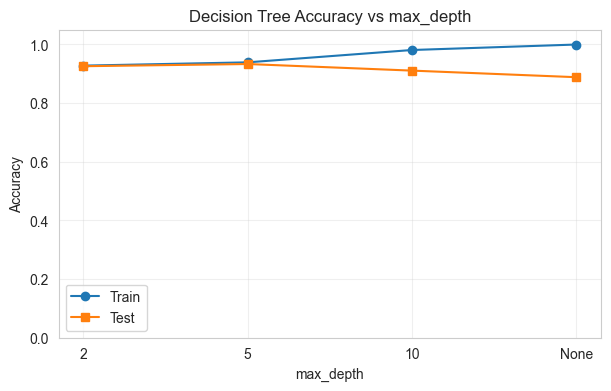

In [94]:

# Decision Tree: train vs test accuracy across depths
plt.figure(figsize=(7, 4))
plt.plot([str(d) for d in depths], dt_train_acc, marker='o', label='Train')
plt.plot([str(d) for d in depths], dt_test_acc, marker='s', label='Test')
plt.title('Decision Tree Accuracy vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


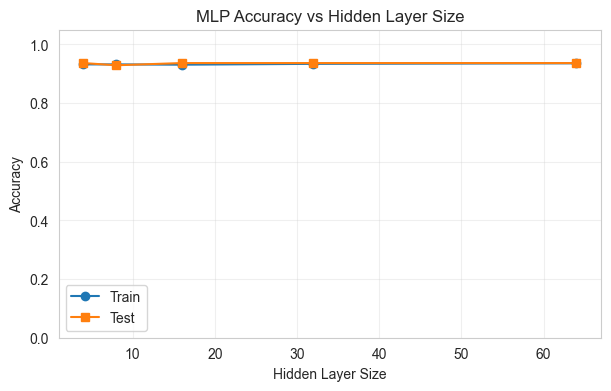

In [95]:

# MLP: train vs test accuracy across hidden sizes
plt.figure(figsize=(7, 4))
plt.plot(sizes, mlp_train_acc, marker='o', label='Train')
plt.plot(sizes, mlp_test_acc, marker='s', label='Test')
plt.title('MLP Accuracy vs Hidden Layer Size')
plt.xlabel('Hidden Layer Size')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


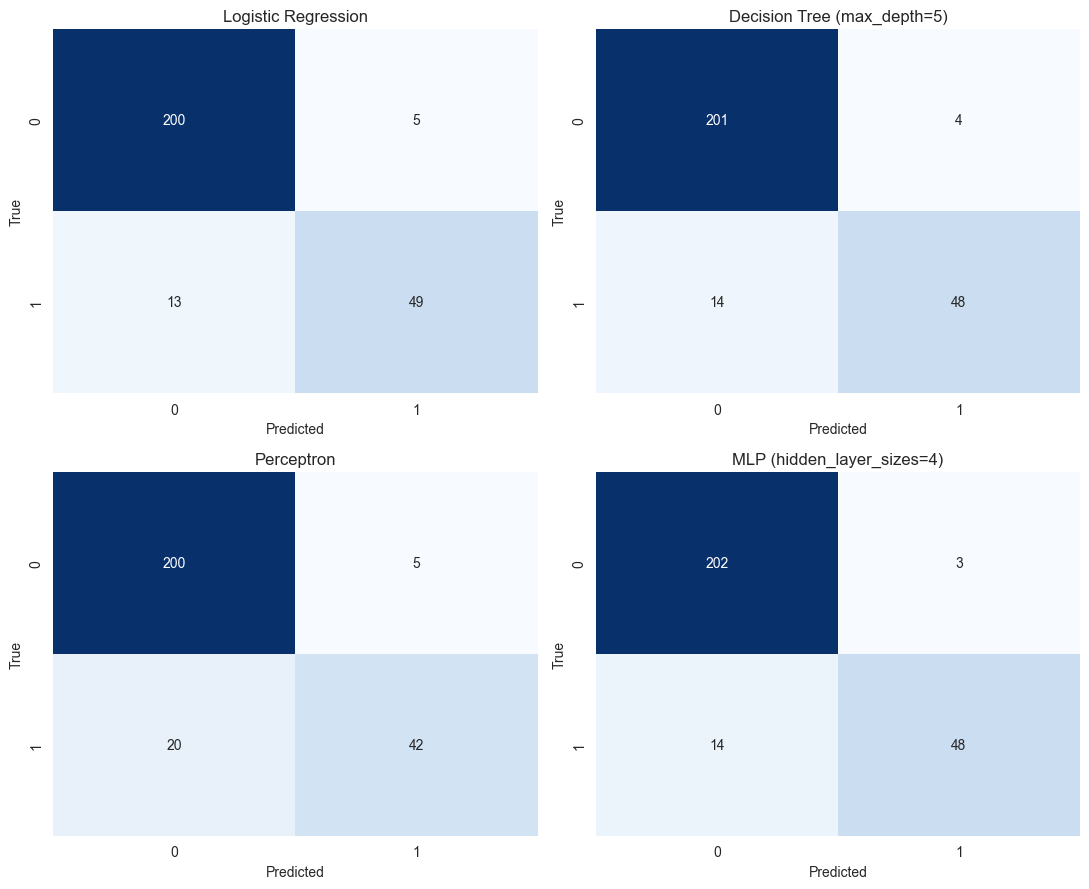

In [97]:

# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, model_name in zip(axes.ravel(), comparison_df['Model']):
    sns.heatmap(conf_mats[model_name], annot=True, fmt='d', cbar=False, cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()


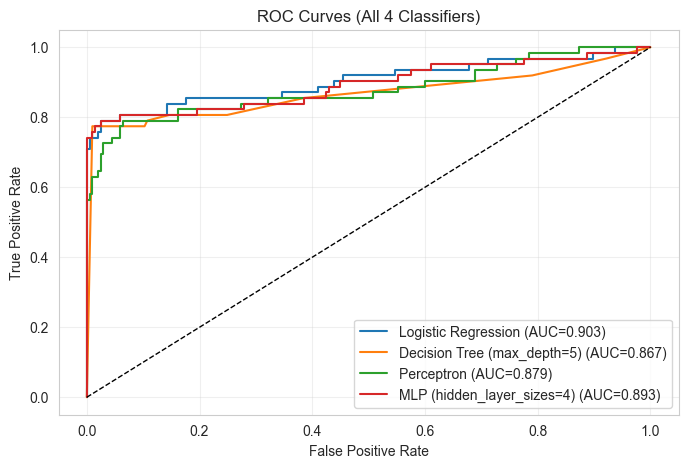

In [98]:

# Combined ROC curves
plt.figure(figsize=(8, 5))
for _, r in comparison_df.iterrows():
    name = r['Model']
    fpr, tpr = roc_data[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['ROC_AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curves (All 4 Classifiers)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()



**Recommended model:** 
It has the best overall balance (highest F1 score).

- Highest Recall: **{best_recall['Model']}** ({best_recall['Recall']:.3f})
- Highest Precision: **{best_precision['Model']}** ({best_precision['Precision']:.3f})

In health insurance, **recall is usually more important** for high-risk detection, because missing a truly high-risk patient can be costly and unsafe.  
Precision still matters to avoid too many false alarms, so choose a model with strong recall but reasonable precision.